In [9]:
import pandas as pd
import nibabel as nib
from collections import Counter

df = pd.read_excel("data/participants.xlsx")
df['path'] = df['subject_id'].apply(lambda x: f"data/{x}/anat/{x}_T1w.nii.gz")
df = df[df['path'].apply(os.path.exists)]

shapes = []
for path in df['path']:
    try:
        img = nib.load(path)
        shape = img.shape
        shapes.append(shape)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        shapes.append(None)

shape_counts = Counter([s for s in shapes if s is not None])

print("\n📊 Shape statistics:")
for shape, count in shape_counts.items():
    print(f"Shape {shape}: {count} samples")

print(f"\n✅ Total valid images: {len([s for s in shapes if s is not None])}")
print(f"❌ Failed to load: {shapes.count(None)} images")


📊 Shape statistics:
Shape (130, 130, 130): 4948 samples

✅ Total valid images: 4948
❌ Failed to load: 0 images


In [1]:
import pandas as pd

file_path = 'data/participants.xlsx'
df = pd.read_excel(file_path)

# Delete '005600' & '019983'
df = df[~df['subject_id'].isin([ 'sub-BrainAge005600', 'sub-BrainAge019983' ])]

# Update the 'No.' column
df['No.'] = range(1, len(df) + 1)

df.to_excel(file_path, index=False)
print("File updated successfully!")

File updated successfully!


In [5]:
import pandas as pd

df = pd.read_excel("data/participants.xlsx")

# Remove subject_id lines start with '014'
df_filtered = df[~df['subject_id'].astype(str).str.startswith("sub-BrainAge014")]
df_filtered['No.'] = range(1, len(df_filtered) + 1)
df_filtered.to_excel("participants_1.xlsx", index=False)

/tmp/ipykernel_5001/2274523866.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['No.'] = range(1, len(df_filtered) + 1)


In [5]:
import pandas as pd

df = pd.read_excel('data/participants_1.xlsx')

sex_counts = df['subject_sex'].value_counts()
print(sex_counts)

subject_sex
f    2830
m    2094
Name: count, dtype: int64


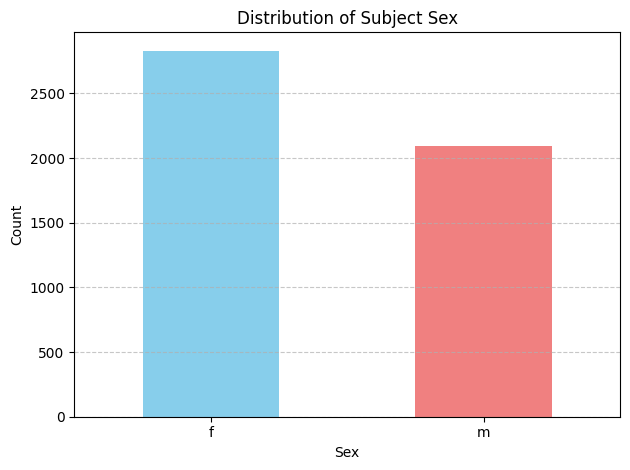

In [3]:
import matplotlib.pyplot as plt

sex_counts = df['subject_sex'].value_counts()

sex_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Subject Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Giữ nhãn trục x nằm ngang
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
def is_integer(n):
    return float(n).is_integer()

n_total = len(df)
n_integer = df['subject_age'].apply(is_integer).sum()
n_decimal = n_total - n_integer

print(f"Samples with integer age values: {n_integer}")
print(f"Samples with decimal age values: {n_decimal}")

Samples with integer age values: 4218
Samples with decimal age values: 706


In [18]:
print(df['subject_age'].describe())

count    4924.000000
mean       45.507842
std        21.637349
min        18.000000
25%        22.375000
50%        46.000000
75%        65.000000
max        97.000000
Name: subject_age, dtype: float64


In [19]:
df = pd.read_excel("data/participants_1.xlsx")
df['subject_age'] = df['subject_age'].astype(int)

age_counts = df['subject_age'].value_counts().sort_index()

age_counts_df = pd.DataFrame({
    'age': age_counts.index,
    'count': age_counts.values
})

pd.set_option('display.max_rows', None)
age_counts_df

,age,count
0,18,121
1,19,290
2,20,411
3,21,264
4,22,157
5,23,136
6,24,124
7,25,99
8,26,69
9,27,68


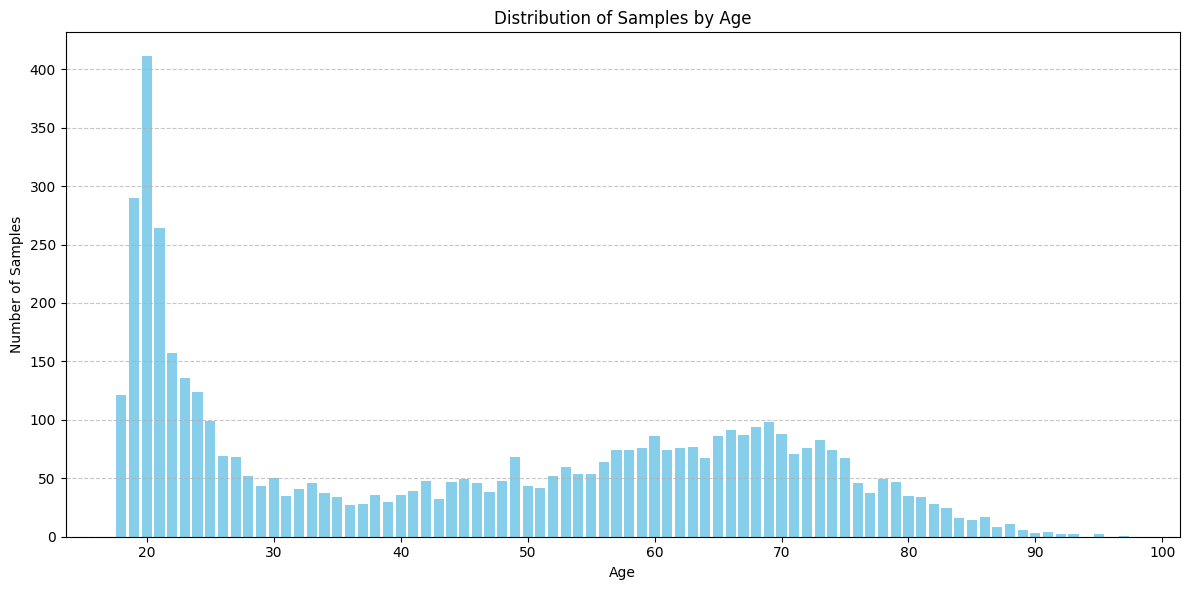

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(age_counts_df['age'], age_counts_df['count'], color='skyblue')
plt.xlabel('Age')
plt.ylabel('Number of Samples')
plt.title('Distribution of Samples by Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()